In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, recall_score
import seaborn as sns

In [3]:
#reading the dataset
df = pd.read_csv(r"/kaggle/input/competitions/playground-series-s5e12/train.csv")
df_test = pd.read_csv(r"/kaggle/input/competitions/playground-series-s5e12/test.csv")
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

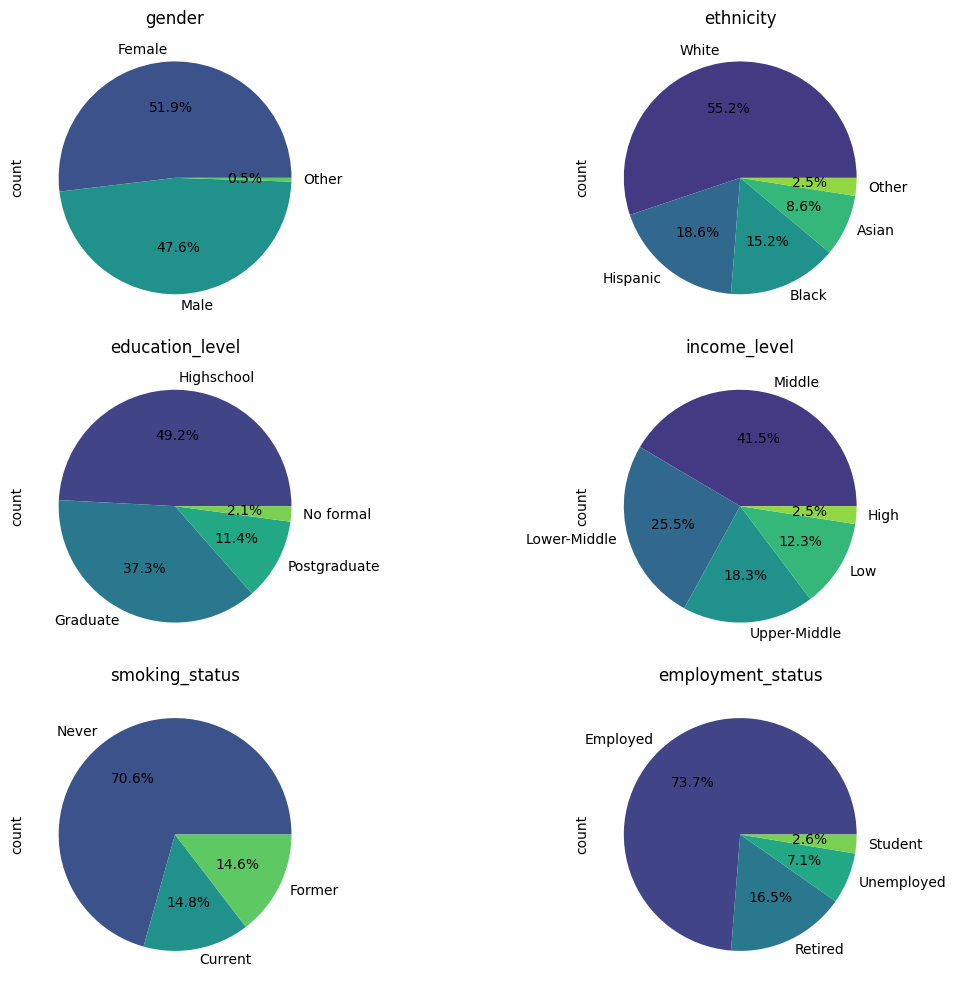

In [7]:
cat_cols = ['gender','ethnicity','education_level','income_level','smoking_status','employment_status']
fig,axes = plt.subplots(3,2,figsize=(12,10))
axes = axes.flatten()
for i,col in enumerate(cat_cols) :
    counts = df[col].value_counts()
    colors = sns.color_palette("viridis",n_colors=len(counts))
    counts.plot(
        kind="pie",
        ax = axes[i],
        colors = colors,
        autopct='%1.1f%%')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [8]:
cols = df.columns
cat_int = []
cols_hist=[]
for c in cols:
    n = df[c].nunique()
    if n < 10 and df[c].dtype!=object:
        cat_int.append(c)
    elif n>10 and df[c].dtype!=object :
        cols_hist.append(c)

In [9]:
cat_int

['alcohol_consumption_per_week',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'diagnosed_diabetes']

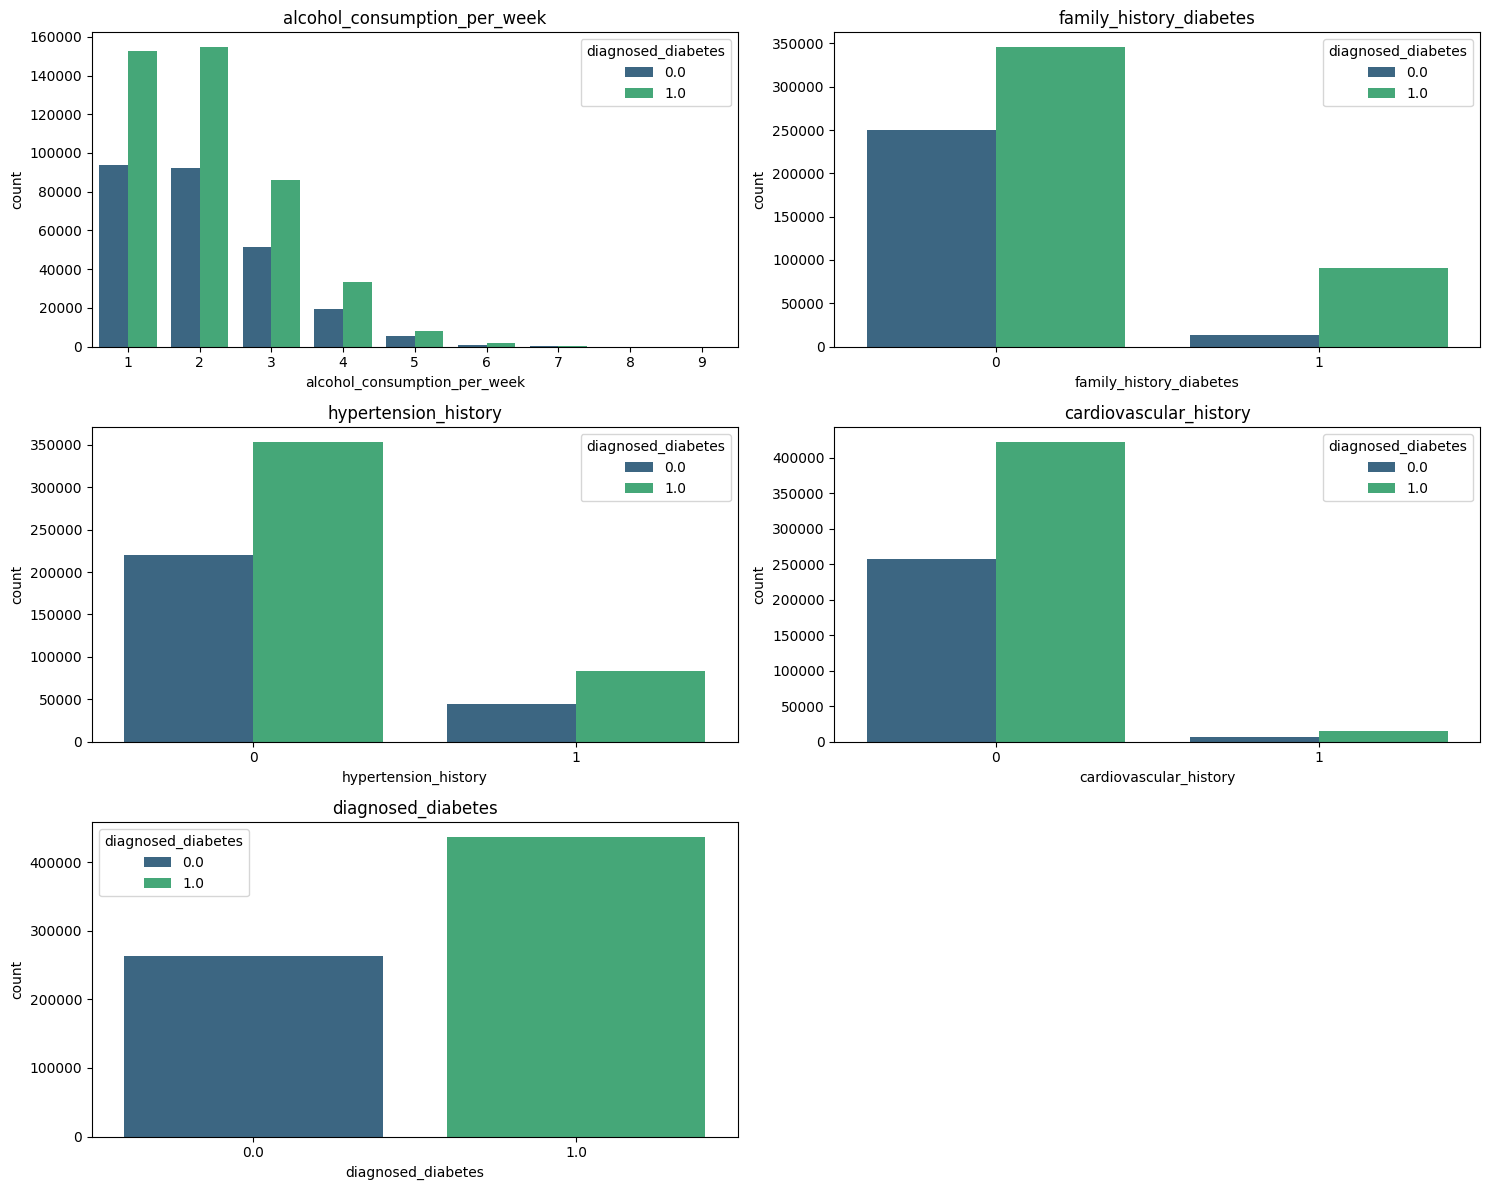

In [10]:
fig = plt.figure(figsize = (15,12))
for i,col in enumerate(cat_int):
    ax=fig.add_subplot(3,2,i+1)
    sns.countplot(data=df,x=col,ax=ax,hue='diagnosed_diabetes',palette='viridis')
    ax.set_title(col)

fig.tight_layout()
plt.show()

In [11]:
cols_hist.remove('id')

In [12]:
cols_hist

['age',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides']

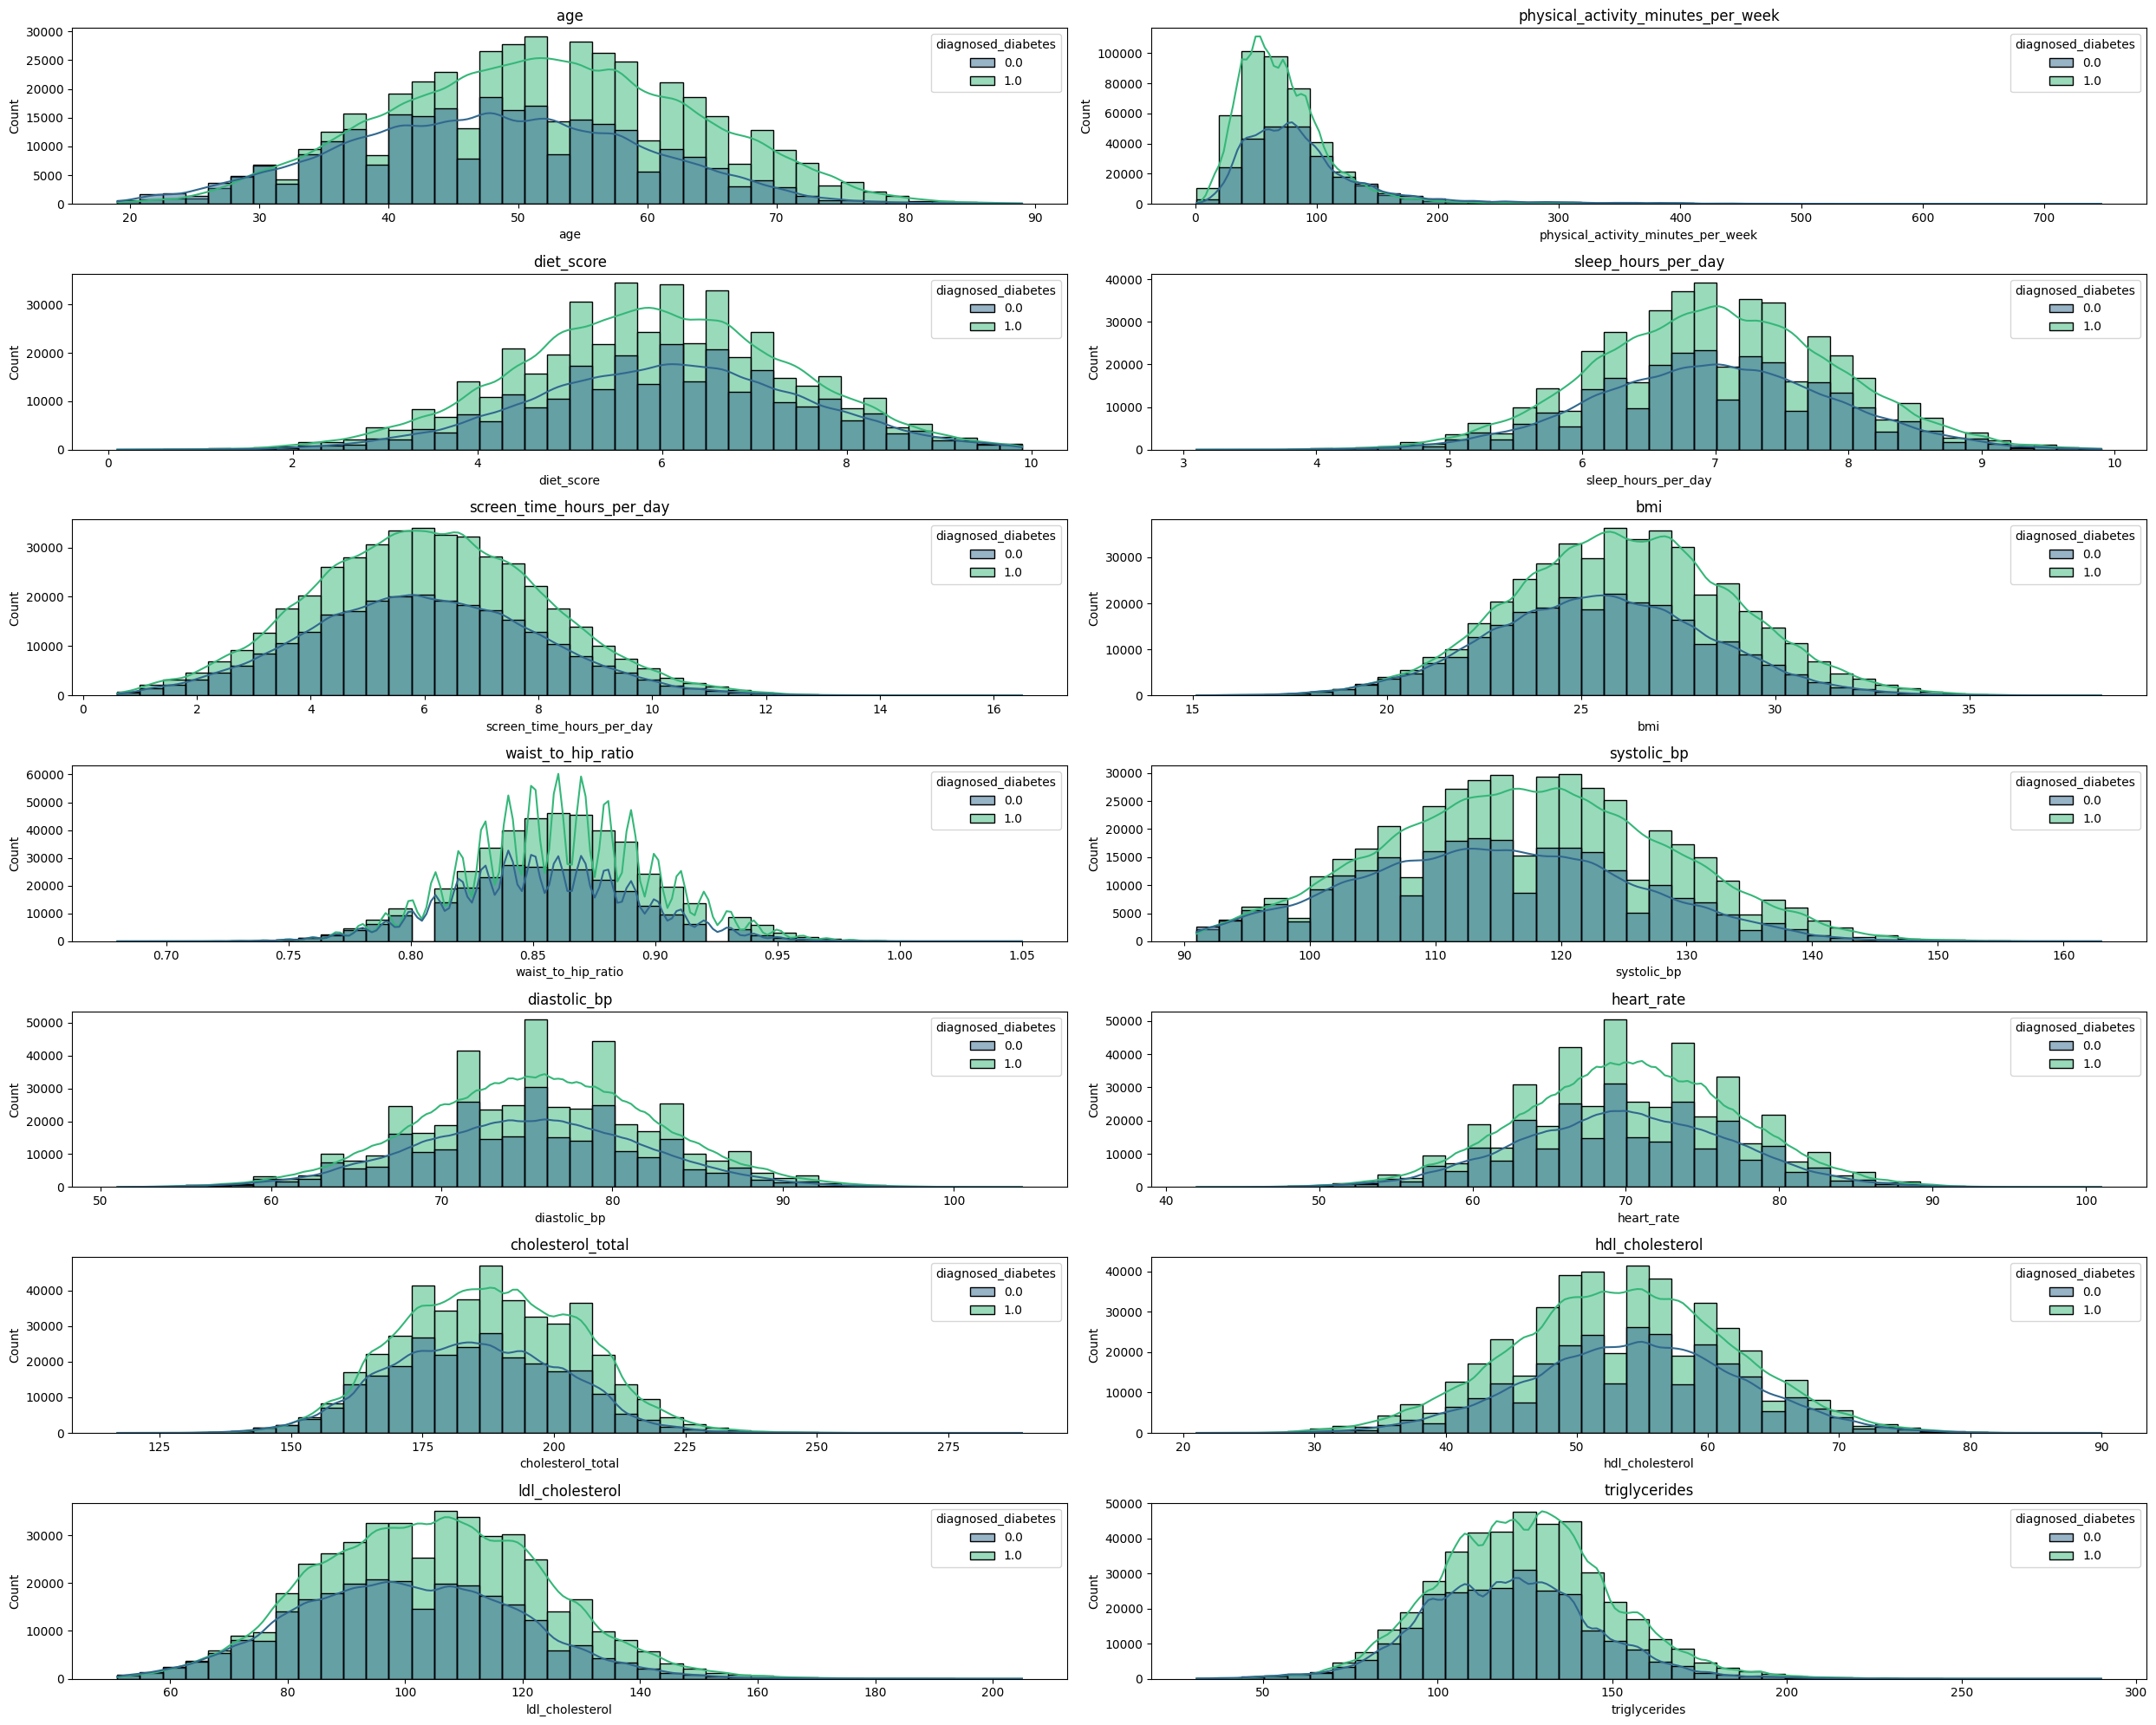

In [13]:
fig = plt.figure(figsize=(25,20))
for i , col in enumerate(cols_hist):
    ax=fig.add_subplot(7,2,i+1)
    sns.histplot(data=df,x=col,ax=ax,hue='diagnosed_diabetes',palette='viridis',kde=True,bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

<Axes: >

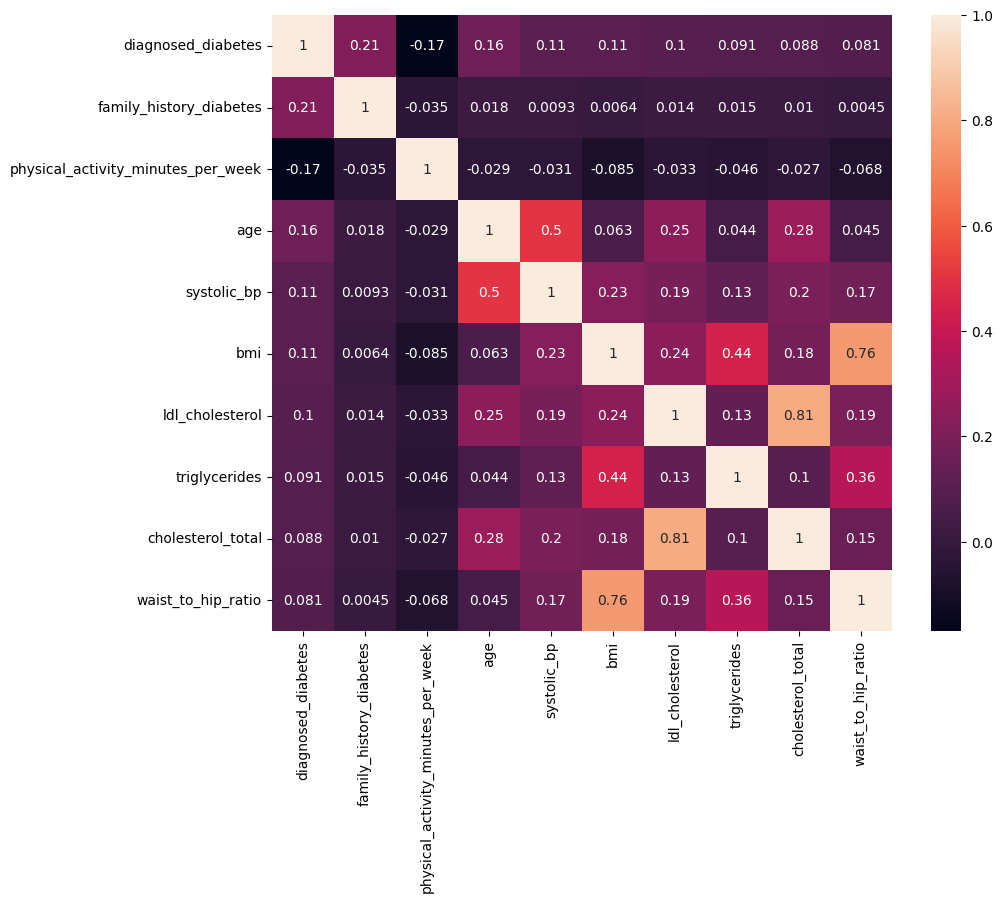

In [14]:
#correlation 
corr_matrix = df.corr(numeric_only=True)
diabetes_corr = corr_matrix['diagnosed_diabetes'].abs().sort_values(ascending=False).head(10)
top_feat = diabetes_corr.index
plt.figure(figsize=(10,8))
sns.heatmap(df[top_feat].corr(),annot=True)

In [16]:
df['diagnosed_diabetes'].value_counts(normalize=True)

diagnosed_diabetes
1.0    0.623296
0.0    0.376704
Name: proportion, dtype: float64

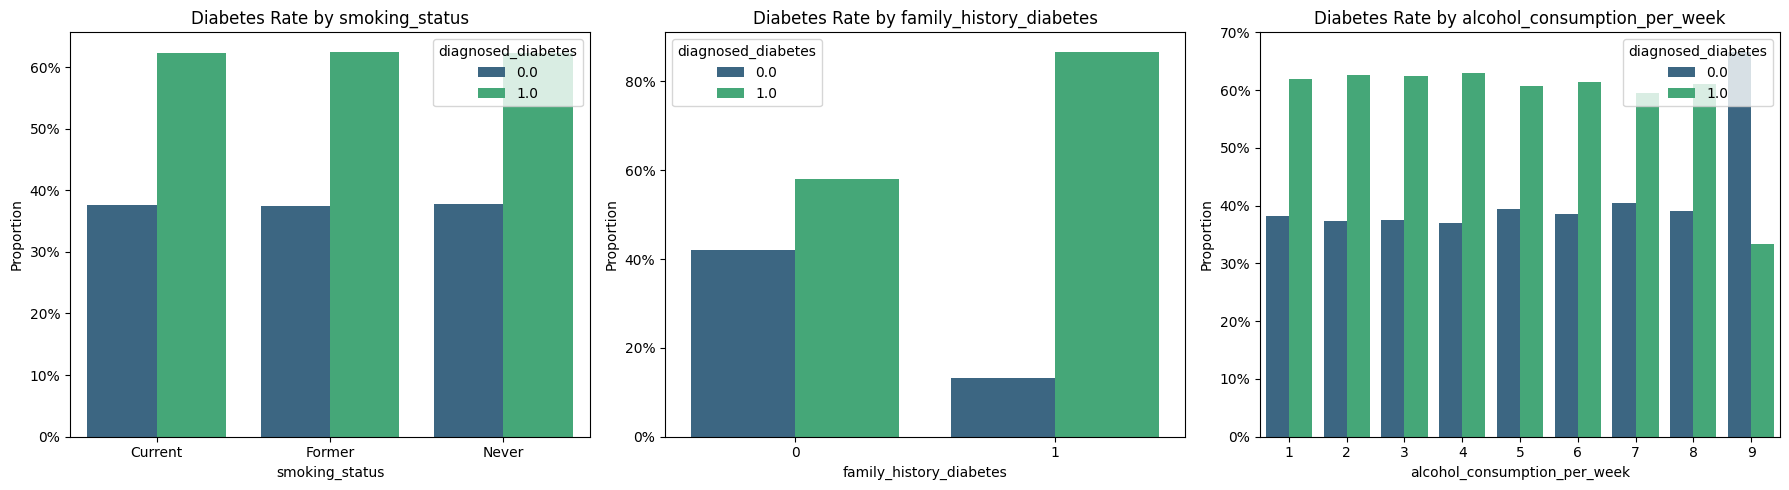

In [17]:
# Normalized countplot to show RATE of diabetes per group
def plot_normalized(col, ax):
    # Calculate percentage of diabetics within each category
    normalized = (df.groupby(col)['diagnosed_diabetes']
                    .value_counts(normalize=True)
                    .rename('percentage')
                    .reset_index())
    
    sns.barplot(data=normalized, x=col, y='percentage', 
                hue='diagnosed_diabetes', ax=ax, palette='viridis')
    ax.set_title(f'Diabetes Rate by {col}')
    ax.set_ylabel('Proportion')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Pick 3 features to test your hypotheses
features_to_check = ['smoking_status', 'family_history_diabetes', 'alcohol_consumption_per_week']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(features_to_check):
    plot_normalized(col, axes[i])

plt.tight_layout()
plt.show()

In [18]:
df.isna().sum().sort_values(ascending = False)

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [19]:
#encoding
nominal = ['gender','ethnicity','smoking_status','employment_status']
combined = pd.concat([df,df_test],axis=0)
combined = pd.get_dummies(combined,columns=nominal,drop_first=True,dtype='int')

In [20]:
df['education_level'].unique()

array(['Highschool', 'Graduate', 'Postgraduate', 'No formal'],
      dtype=object)

In [21]:
income = ['Low','Lower-Middle','Middle', 'Upper-Middle','High']
edu = ['No formal','Highschool','Graduate','Postgraduate']
combined['education_level']=combined['education_level'].map({k: i for i, k in enumerate(edu)})
combined['income_level']=combined['income_level'].map({k:i for i, k in enumerate(income)})

In [22]:
combined.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender_Other,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,smoking_status_Former,smoking_status_Never,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,0,0,1,0,0,0,0,0,0,0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,0,0,0,0,1,0,1,0,0,0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,0,0,1,0,0,0,1,1,0,0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,0,0,0,0,1,0,0,0,0,0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,0,0,0,0,1,0,1,1,0,0


In [23]:
n_train = len(df)
df_train_encoded = combined.iloc[:n_train].copy()
df_test_encoded = combined.iloc[n_train:].copy()

In [24]:
def add_feat(df):
    df['phisycBmi']=df['bmi'] / (df['physical_activity_minutes_per_week'] + 1)
    df['famAge']=df['family_history_diabetes']*df['age']
    return df

df_test_encoded = add_feat(df_test_encoded)
df_train_encoded=add_feat(df_train_encoded)

In [25]:
x = df_train_encoded.drop(columns=['id','diagnosed_diabetes'])
y = df_train_encoded['diagnosed_diabetes']
x_train, x_test, y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [26]:
#logistic regresion 
lreg = LogisticRegression(max_iter=1000)
lreg.fit(x_train,y_train)
lr_probs = lreg.predict_proba(x_test)[:,1]
print(f"LR ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")

LR ROC-AUC: 0.6939


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
#random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
rf_probs = rf.predict_proba(x_test)[:,1]
print(f"Rf ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")

Rf ROC-AUC: 0.6957


In [28]:
import lightgbm as lgb
n = (y_train==0).sum()
p = (y_train==1).sum()
rati = n/p
print(f"ratio of y dataset : {rati:.2f}")


ratio of y dataset : 0.60


In [29]:
lgbm = lgb.LGBMClassifier(n_estimators=1000,learning_rate=0.05,num_leaves=31,scale_pos_weight=rati,random_state=42,n_jobs=-1)
lgbm.fit(x_train,y_train,
         eval_set=[(x_test,y_test)],
         callbacks=[lgb.early_stopping(50),lgb.log_evaluation(100)])
lgbm_probs = lgbm.predict_proba(x_test)[:,1]
print(f"lgbm ROC-AUC: {roc_auc_score(y_test,lgbm_probs):.4f}")

[LightGBM] [Info] Number of positive: 349046, number of negative: 210954
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1981
[LightGBM] [Info] Number of data points in the train set: 560000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.623296 -> initscore=0.503564
[LightGBM] [Info] Start training from score 0.503564
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.616935
[200]	valid_0's binary_logloss: 0.612849
[300]	valid_0's binary_logloss: 0.611334
[400]	valid_0's binary_logloss: 0.610604
[500]	valid_0's binary_logloss: 0.610172
[600]	valid_0's binary_logloss: 0.609629
[700]	valid_0's binary_logloss: 0.609345
[800]	valid_0's binary_logloss: 0.609149
[900]	valid_0's binary_logloss: 0.608941
[1000]	vali

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


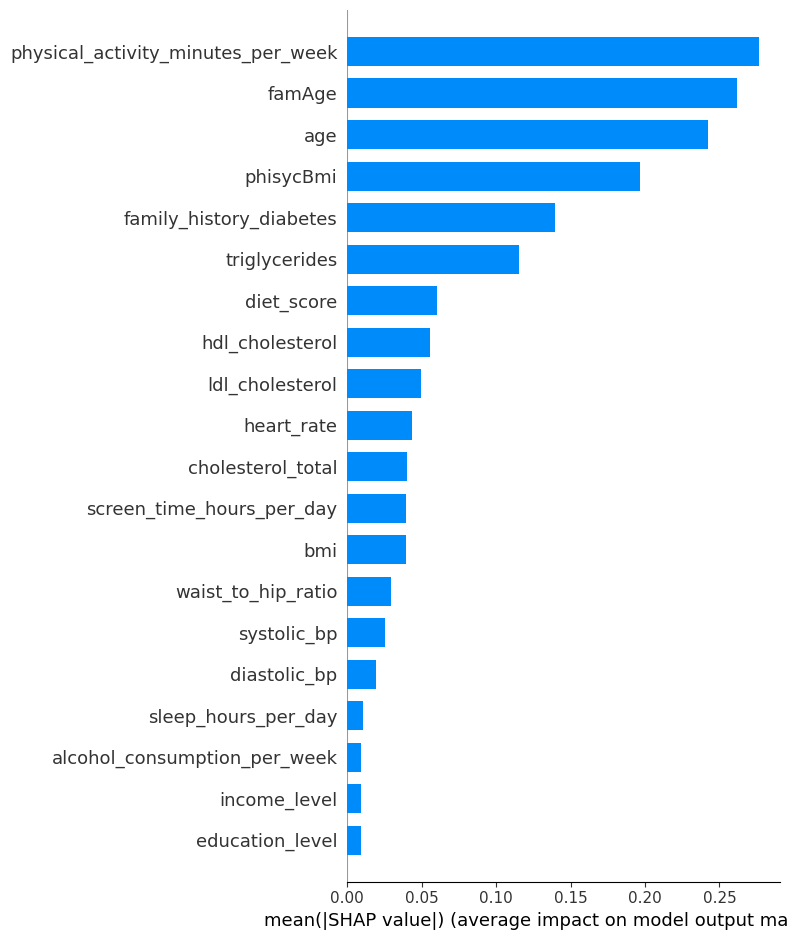

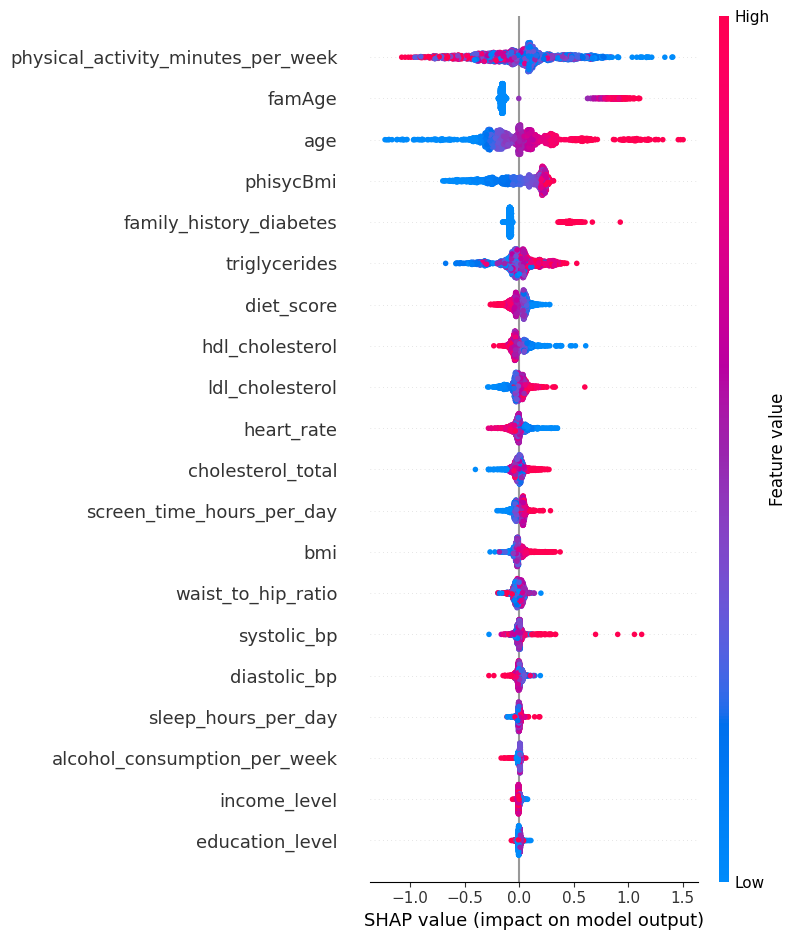

In [30]:
import shap

# Use a sample for speed (SHAP on 700k rows is slow)
sample_idx = x_test.sample(2000, random_state=42).index
x_sample = x_test.loc[sample_idx]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(x_sample)

# Global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, x_sample, plot_type="bar", show=True)

# Full beeswarm plot (shows direction too)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, x_sample, show=True)

In [31]:
from sklearn.model_selection import StratifiedKFold
scores=[]
skf = StratifiedKFold(n_splits = 5)
for train_index , test_index in skf.split(x,y):
    x_train_fold, x_test_fold = x.iloc[train_index], x.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    lgbm.fit(x_train_fold,y_train_fold)
    lgbm_probs = lgbm.predict_proba(x_test_fold)[:,1]
    scores.append(roc_auc_score(y_test_fold,lgbm_probs))
print(f"Mean AUC: {np.mean(scores):.4f}")

[LightGBM] [Info] Number of positive: 349045, number of negative: 210955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1975
[LightGBM] [Info] Number of data points in the train set: 560000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.623295 -> initscore=0.503556
[LightGBM] [Info] Start training from score 0.503556
[LightGBM] [Info] Number of positive: 349045, number of negative: 210955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1976
[LightGBM] [Info] Number of data points in the train set: 560000, number of used features: 33
[LightGBM] [In

In [32]:
#trainig on full data
df_test_encoded=df_test_encoded.drop(columns=['id','diagnosed_diabetes'])
flgbm = lgb.LGBMClassifier(n_estimators=1000,learning_rate=0.0615,num_leaves=61,scale_pos_weight=rati,random_state=42,min_child_samples=91,subsample=0.7087,n_jobs=-1)
flgbm.fit(x,y)
flgbm_probs = flgbm.predict_proba(df_test_encoded)[:,1]
result = pd.DataFrame({'id':df_test['id'], 'diagnosed_diabetes':flgbm_probs} )
result.to_csv('submission.csv', index=False)

[LightGBM] [Info] Number of positive: 436307, number of negative: 263693
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1977
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.623296 -> initscore=0.503561
[LightGBM] [Info] Start training from score 0.503561
